# Analysis of Covid-19 Vulnerability, Symptoms, and Factors
#### Data from Jain, S., Charpignon, M., Samuel, M., Mistry, ..., Frosst, N. Cli, L.A., & Ghaseemi, M. (2021) Flatten: COVID-19 Survey Data on Symptoms, Demographics and Mental Health in Canada (version 1.0).  PhysioNet. 

#### Notebook created by Deborah Won

#### Edited by Esmeralda Amado

In [1]:
##  Use this cell to add more imports as you find more libraries you need while going through this notebook

In [2]:
import pandas as pd

pth = "/Users/esmeraldaamado/Downloads/"
fname = "schema_3_ontario_final.csv"
data = pd.read_csv(pth + fname)

In [3]:
# QUESTION: How many variables are there?

# there are 26 variables
# there is 15534 samples

print(data.shape)

#defining variables
dataShape = data.shape
Nvar = dataShape[1]
print(f'The number of variables is {Nvar}')


(15534, 26)
The number of variables is 26


In [4]:
# QUESTION: How many samples are in this dataset?

# there is 15534 samples
print(f'The number of samples is {dataShape[0]}')


The number of samples is 15534


In [5]:
# QUESTION: List the variables that were collected in this survey
print(data.columns)

# QUESTION: Which variables are categorical? Which are continuous?
# .describe is important, is the favStats command similar, its a method
print(data.describe())


Index(['month', 'fsa', 'probable', 'vulnerable', 'fever_chills_shakes',
       'cough', 'shortness_of_breath', 'any_medical_conditions',
       'travel_outside_canada', 'contact_with_illness', 'contact_in_household',
       'tested', 'covid_results_date', 'covid_positive', 'symptoms',
       'conditions', 'ethnicity', 'sex', 'needs', 'age_1',
       'mental_health_impact', 'travel_work_school', 'self_isolating',
       'media_channels', 'financial_obligations_impact', 'tobacco_usage'],
      dtype='object')
        month    fsa probable vulnerable fever_chills_shakes  cough  \
count   15534  15534    15534      15534               15534  15534   
unique      4    309        2          2                   2      2   
top       May    M6P        n          n                   n      n   
freq     6698    220    15341      12616               15286  15309   

       shortness_of_breath any_medical_conditions travel_outside_canada  \
count                15534                  15534       

In [6]:
# Extract only the 'probable' column in the dataframe
probable = data["probable"]

# QUESTION: What type of variable is this new 'probable' variable (the column from the dataframe)?
print(type(probable))

# probable is a series thats categorical

<class 'pandas.core.series.Series'>


In [7]:
# What were the possible responses for the 'probable' variable?
# unique gives all the unique values in an array, its categorical, boolean values
probable.unique()

array(['n', 'y'], dtype=object)

In [8]:
# How many respondents were deemed probable to have Covid-19?  
# How many respondents were deemed not probable to have Covid-19?  
probable.value_counts()

probable
n    15341
y      193
Name: count, dtype: int64

In [9]:
# Create a Boolean array of True/False indicating whether it is true that the respondent was deemed to probably have Covid-19

covidProbableBool = probable=='y'

print(covidProbableBool.unique())
print(covidProbableBool)

[False  True]
0        False
1        False
2        False
3        False
4        False
         ...  
15529    False
15530    False
15531    False
15532    False
15533    False
Name: probable, Length: 15534, dtype: bool


In [10]:
# QUESTION: How many respondents were probable for Covid-19? How many were not probable for Covid-19?

probable0or1 = probable.value_counts()
print(type(probable0or1)) #its a series
print(probable0or1) #value count
print(probable0or1.values) #actual values
print(type(probable0or1.values)) #puts it in a numpy array

<class 'pandas.core.series.Series'>
probable
n    15341
y      193
Name: count, dtype: int64
[15341   193]
<class 'numpy.ndarray'>


In [11]:
# QUESTION: What proportion of the respondents have probable Covid? do not have probably Covid?

print(probable0or1.values/sum(probable0or1.values))

[0.98757564 0.01242436]


([<matplotlib.patches.Wedge at 0x147164cd0>,
 [Text(-1.099162177285674, 0.04292444553651438, 'n'),
  Text(1.0991621708042503, -0.04292461150538519, 'y')],
 [Text(-0.5995430057921857, 0.02341333392900784, '98.8%'),
  Text(0.5995430022568637, -0.023413424457482828, '1.2%')])

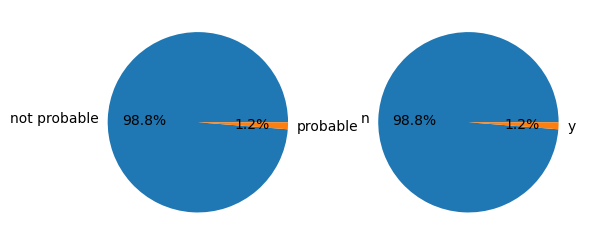

In [12]:
# Create a pie chart showing the proportion of subjects who were deemed to probably have Covid vs those who were not.
# QUESTION: What percentage have probable Covid?

import matplotlib.pyplot as plt

# making sperate pie charts. 1=row, 2=columns
plt.subplot(1,2,1)
plt.pie(probable0or1, labels=['not probable', 'probable'], autopct='%1.1f%%')

plt.subplot(1,2,2)
plt.pie(probable0or1, labels=probable.unique(), autopct='%1.1f%%')

In [13]:
data.head(6)

,month,fsa,probable,vulnerable,fever_chills_shakes,cough,shortness_of_breath,any_medical_conditions,travel_outside_canada,contact_with_illness,...,ethnicity,sex,needs,age_1,mental_health_impact,travel_work_school,self_isolating,media_channels,financial_obligations_impact,tobacco_usage
0,April,M4P,n,n,n,n,n,y,n,n,...,NaN,NaN,noneOfTheAbove,<26,NaN,NaN,NaN,NaN,NaN,NaN
1,April,M9P,n,n,n,n,n,y,n,n,...,caucasian,f,food,<26,noImpact,stoppedTravelling,y,twitter;tv;reddit,NaN,n
2,April,K0L,n,n,n,n,n,y,n,n,...,NaN,NaN,noneOfTheAbove,45-64,NaN,NaN,NaN,NaN,NaN,NaN
3,April,N9E,n,n,n,n,n,y,n,n,...,NaN,NaN,noneOfTheAbove,45-64,NaN,NaN,NaN,NaN,NaN,NaN
4,April,L2N,n,n,n,n,n,y,n,n,...,NaN,NaN,financialSupport,<26,NaN,NaN,NaN,NaN,NaN,NaN
5,April,M6S,n,n,n,n,n,y,n,n,...,caucasian,f,noneOfTheAbove,26-44,noImpact,stoppedTravelling,y,tv;facebook;instagram,NaN,quitSmoking


In [14]:
# Extract those responses with probable Covid and put in a new dataframe called withCovid
withCovid = data.loc[data["probable"]=="y"]

In [15]:
# QUESTION: How many respondents have probable Covid-19?
withCovid.shape

(193, 26)

In [16]:
# QUESTION: How many respondents do not have probable Covid-19?
noCovid = data.loc[data["probable"]=="n"] #extracting the ones that equal to no

noCovid.shape

(15341, 26)

In [44]:
# QUESTION: What are the different possible age categories in this survey?  Are any age groups different? 
print(withCovid['age_1'].unique()) #all possible ages that are probable of having covid

# what about without covid
print(noCovid['age_1'].unique())

['45-64' '26-44' '>65' '<26']
['<26' '45-64' '26-44' '>65']


age_1
45-64    6218
26-44    5434
>65      2004
<26      1685
Name: count, dtype: int64
Index(['45-64', '26-44', '>65', '<26'], dtype='object', name='age_1')
Index(['<26', '26-44', '45-64', '>65'], dtype='object', name='age_1')
age_1
26-44    84
45-64    62
<26      37
>65      10
Name: count, dtype: int64
Index(['26-44', '45-64', '<26', '>65'], dtype='object', name='age_1')
Index(['<26', '26-44', '45-64', '>65'], dtype='object', name='age_1')


[Text(0, 0, '<26'),
 Text(1, 0, '26-44'),
 Text(2, 0, '45-64'),
 Text(3, 0, '>65')]

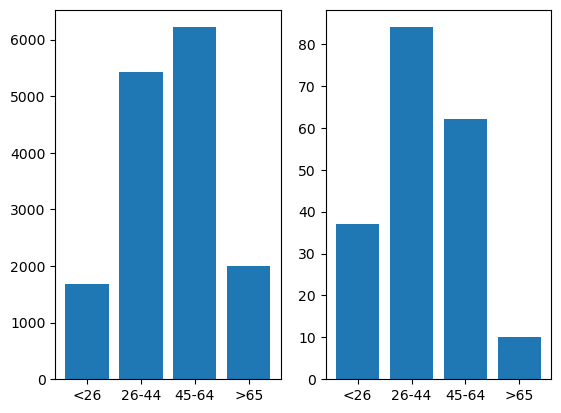

In [46]:
# Compare the age distribution of people who probably have Covid vs those who do not by using a bar plot
ageNoCovid = noCovid['age_1'].value_counts()
print(ageNoCovid)
ageGrps = ageNoCovid.index
print(ageGrps)
order = [3, 1, 0, 2]
print(ageGrps[order])

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.bar(range(4), ageNoCovid.values[order]) #pandas course series
ax1.set_xticks(range(4))
ax1.set_xticklabels(ageGrps[order])

ageCovid = withCovid['age_1'].value_counts()
print(ageCovid)
ageGrps = ageCovid.index
print(ageGrps)
order = [2, 0, 1, 3]
print(ageGrps[order])

ax2.bar(range(4), ageCovid.values[order])
ax2.set_xticks(range(4))
ax2.set_xticklabels(ageGrps[order])

# ADD APPROPRIATE LABELS and TITLES

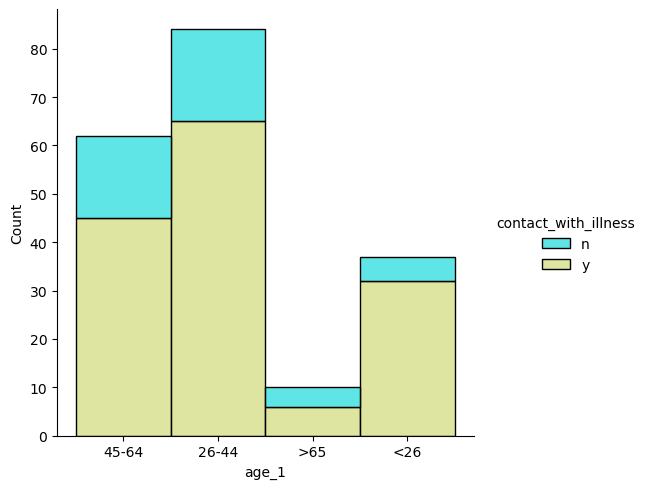

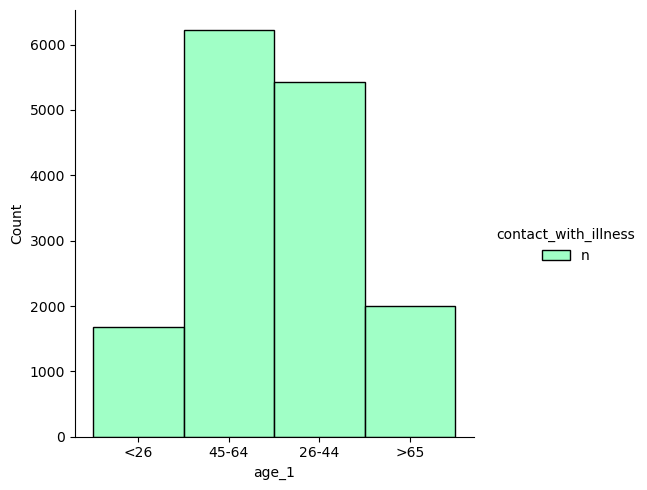

In [25]:
# Create a stacked bar chart showing age as the primary factor and contact with illness as a secondary factor

#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/esmeraldaamado/Downloads/schema_3_ontario_final.csv")

# creating covidDF and noCovidDF
covidDF = df[df["probable"] == "y"]
noCovidDF = df[df["probable"] == "n"]


# First show the distribution for those with probable covid:
covidPlt= sns.displot(data= covidDF, x = "age_1", hue= "contact_with_illness" , palette="rainbow",multiple="stack" )

# FILL IN THE BLANK: Compare the stacked bar chart for those probably having Covid-19 with those probably not having Covid-19
noCovidPlt= sns.displot(data= noCovidDF, x = "age_1", hue= "contact_with_illness" , palette="rainbow",multiple="stack" )

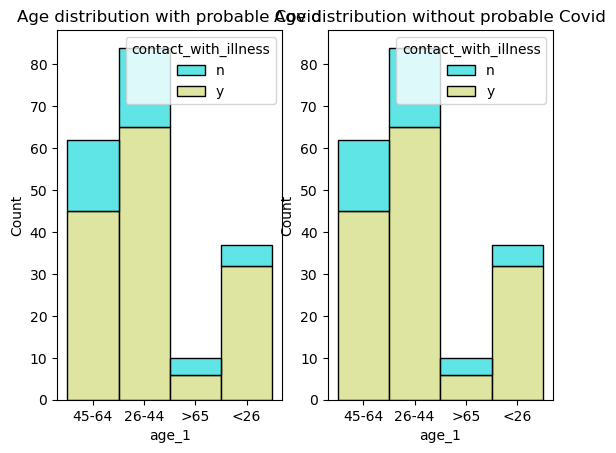

In [26]:
# Try using a histplot and subplots to compare side by side those w/ and w/o probably covid.  
# Use a stacked histogram plot to show the distrubtion by age for people with probable covid 
# and compare with the distribution by age for those who do not have probable Covid.
# Stack by contact with illness.

fig, (ax1, ax2) = plt.subplots(1, 2)

sns.histplot(data= covidDF, x = "age_1" , hue= "contact_with_illness" , palette="rainbow",multiple="stack", ax=ax1)

# FILL IN THE BLANK for those who do not have probable covid
sns.histplot(data= covidDF, x = "age_1" , hue= "contact_with_illness" , palette="rainbow",multiple="stack", ax=ax2)

# FILL IN THE BLANK with appropriate titles
ax1.title.set_text("Age distribution with probable Covid")
ax2.title.set_text("Age distribution without probable Covid")

QUESTION: What do these histograms show you?
Comment on the comparison between the age distribution of those with probable covid vs those with no probable covid.

- they show the same thing on both sides. the age barely changes whether someone's marked as probable covid or not

## Compare two more factors using pie charts. You may also include bar charts / histograms
### 1) does travel outside Canada seem to influence whether someone is more likely to have Covid or not? 

- travel doesn't look like a risk factor. The proportions look the same for both groups

###    i.e., is travel outside Canada a risk factor?
### 2) does sex/gender seem to influence whether someone is more likely to have Covid or not?

- gender doesn't seem to matter, both groups have similar splits